# Item-Level Descriptives EDA (Authors vs Foils)

Input dataset:
- `data/stepwise_cleaned_versions/03_participant_demographics_normalized_categories/ART_pretest_(for Castano)_EN__participant_demographics_step04_normalized_categories.csv`

Goals:
1. Print all author items and all foil items separately (quick cleaning audit)
2. Compute item-level descriptives:
   - item type (author vs foil)
   - endorsement proportion (`p`)
   - missing rate
   - corrected item-total correlation for author items
   - for foil items: correlation with participant corrected score and with false-alarm tendency
3. Apply pragmatic flag thresholds (for review, not auto-deletion):
   - endorsement `< .05` or `> .95`
   - corrected item-total `< .10` or negative (authors)
   - foil endorsement clearly above foil pool (95th percentile)
   - very high missingness
4. Plot author genre distribution (counts and endorsement profile)

Why this pass matters:
- Very low endorsement for authors can indicate overly difficult or culturally obsolete items
- Very high endorsement for authors can indicate overly easy items
- Near-zero/negative corrected item-total can indicate dysfunctional items
- High foil endorsement can indicate guessing or weak distractors
- In line with Moore & Gordon logic, difficult items and foil behavior can co-cluster and should be screened descriptively

In [1]:
from pathlib import Path
from difflib import SequenceMatcher
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_rows", 300)
pd.set_option("display.max_colwidth", 160)

In [2]:
# Shared plotting style conventions (kept consistent across EDA notebooks)
# Note: no fixed color mappings here by design.

# Global font and sizing defaults for publication-friendly readability
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "axes.titlepad": 10,
})

# Reusable spacing/annotation constants for bar-like plots
ANNOT_OFFSET_PCT = 0.8
ANNOT_TEXT_FMT = "{pct:.1f}%  (n = {cnt})"


def annotate_bar_values(ax, bars, percents, counts, x_offset=ANNOT_OFFSET_PCT, fontsize=10):
    """Write percent + count labels in a uniform style."""
    for bar, pct, cnt in zip(bars, percents, counts):
        ax.text(
            pct + x_offset,
            bar.get_y() + bar.get_height() / 2,
            ANNOT_TEXT_FMT.format(pct=pct, cnt=cnt),
            ha="left",
            va="center",
            fontsize=fontsize,
        )


def finalize_axis(ax, xlabel=None, ylabel=None, title=None, invert_y=False, grid=False):
    """Apply consistent final axis formatting used across notebooks."""
    if xlabel is not None:
        ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    if title is not None:
        ax.set_title(title)
    if invert_y:
        ax.invert_yaxis()
    ax.grid(grid)

    # Consistent spine cleanup for cleaner publication visuals
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

In [3]:
PROJECT_ROOT = Path("..").resolve().parent
DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "stepwise_cleaned_versions"
    / "03_participant_demographics_normalized_categories"
    / "ART_pretest_(for Castano)_EN__participant_demographics_step04_normalized_categories.csv"
)

raw = pd.read_csv(DATA_PATH, header=None)
labels = raw.iloc[0].fillna("").astype(str)
codes = raw.iloc[1].fillna("").astype(str)
responses = raw.iloc[2:, :].reset_index(drop=True)

print(f"Loaded: {DATA_PATH}")
print(f"Rows (participants): {len(responses)}")
print(f"Columns (full width): {raw.shape[1]}")

Loaded: /home/polina/Documents/Cursor_Projects/Russian Author Recognition Test Cursor/data/stepwise_cleaned_versions/03_participant_demographics_normalized_categories/ART_pretest_(for Castano)_EN__participant_demographics_step04_normalized_categories.csv
Rows (participants): 908
Columns (full width): 216


In [4]:
def normalize_code(code: str) -> str:
    return re.sub(r"\s+", "", str(code).strip().lower())


ITEM_CODE_PATTERN = re.compile(r"^(fill\d+|(?:mod|cla|sci|det|fan|soc)\d+)$")

code_norm = codes.map(normalize_code)
item_mask = code_norm.map(lambda x: bool(ITEM_CODE_PATTERN.match(x)))
item_indices = np.flatnonzero(item_mask.to_numpy())

item_labels = labels.iloc[item_indices].astype(str).str.strip().reset_index(drop=True)
item_codes = codes.iloc[item_indices].astype(str).str.strip().reset_index(drop=True)
item_codes_norm = code_norm.iloc[item_indices].reset_index(drop=True)

item_type = np.where(item_codes_norm.str.startswith("fill"), "foil", "author")
item_genre_prefix = item_codes_norm.str.extract(r"^([a-z]+)", expand=False).fillna("")

genre_map = {
    "cla": "Classics",
    "mod": "Modern/Literary",
    "sci": "Sci-Fi",
    "det": "Detective/Thriller",
    "fan": "Fantasy",
    "soc": "Social/Other",
}
item_genre = [genre_map.get(prefix, "Foil") if itype == "author" else "Foil" for prefix, itype in zip(item_genre_prefix, item_type)]

item_meta = pd.DataFrame(
    {
        "item_idx": item_indices,
        "item_label": item_labels,
        "item_code": item_codes,
        "item_code_norm": item_codes_norm,
        "item_type": item_type,
        "genre": item_genre,
    }
)

# Make an always-unique key because some codes are duplicated (for example, repeated fill numbers).
item_meta["item_id"] = [f"{code}__{i:03d}" for i, code in enumerate(item_meta["item_code_norm"]) ]

item_resp = responses.iloc[:, item_indices].apply(pd.to_numeric, errors="coerce")
item_resp = item_resp.where(item_resp.isin([0, 1]))
item_resp.columns = item_meta["item_id"].tolist()

print(f"Detected item columns: {len(item_indices)}")
print(item_meta["item_type"].value_counts().to_string())

Detected item columns: 207
item_type
foil      107
author    100


## 0) Cleaning audit: print all author and foil items separately

In [5]:
# Exclude Richard Feynman ("cla17", index 120) from authors_list and rename "Social/Other" to "SovLit".

# First, fix the genre name
item_meta["genre"] = item_meta["genre"].replace({"Social/Other": "SovLit"})

# Clean foil names in-place in item_meta: remove trailing fill+number artifacts and normalize spaces
# (Use re + item_type so behavior does not depend on pandas regex / JSON escaping in the notebook file.)
_FOIL_FILL_SUFFIX = re.compile(r"(?i)\s*f\s*i\s*l\s*l\s*\d+\s*$")


def _clean_foil_item_label(label) -> str:
    s = _FOIL_FILL_SUFFIX.sub("", str(label))
    return re.sub(r"\s+", " ", s).strip()


foil_mask = item_meta["item_type"].eq("foil")
item_meta.loc[foil_mask, "item_label"] = item_meta.loc[foil_mask, "item_label"].map(_clean_foil_item_label)

# Now exclude Richard Feynman (cla17, index 120)
authors_list = item_meta.loc[
    (item_meta["item_type"] == "author") &
    ~(
        (item_meta["item_label"].str.strip() == "Richard Feynman") &
        (item_meta["item_code_norm"].str.strip() == "cla17")
    ),
    ["item_label", "genre"]
].copy()

foils_list = item_meta.loc[item_meta["item_type"] == "foil", ["item_label", "genre"]].copy()

print(f"Author items: {len(authors_list)}")
display(authors_list.reset_index(drop=True))

print(f"\nFoil items: {len(foils_list)}")
display(foils_list.reset_index(drop=True))

Author items: 99


,item_label,genre
0,Khaled Hosseini,Modern/Literary
1,Donna Tartt,Modern/Literary
2,Archibald Cronin,Classics
3,Gillian Flynn,Detective/Thriller
4,Gabriel Garsia Marquez,Classics
5,James Fenimore Cooper,Classics
6,Henryk Sienkiewicz,Classics
7,Paula Hawkins,Detective/Thriller
8,George Orwell,Sci-Fi
9,Jane Austen,Classics



Foil items: 107


,item_label,genre
0,Gerrit HoogenbuM,Foil
1,Gonzalo Hervas,Foil
2,Richard Gould,Foil
3,Brian Callis,Foil
4,Petr Sabluk,Foil
5,Neil Bourke,Foil
6,Chris Reynolds,Foil
7,Paul Merwick,Foil
8,Secundino Lopez,Foil
9,Vladimir Sidorenko,Foil


## 1) ART scoring setup (author and foil keys kept separate from the start)

This section follows ART scoring tradition for the current instrument version:
- binary item coding (`1 = selected`, `0 = not selected`)
- separate author and foil key lists from the start
- one explicit exclusion only: `Richard Feynman` (`cla17`)

In [6]:
# Final scoring keys for this notebook pass

# Define masks for excluded items
feynman_mask = (
    (item_meta["item_label"].astype(str).str.strip() == "Richard Feynman")
    & (item_meta["item_code_norm"].astype(str).str.strip() == "cla17")
)

# Masks for foils to additionally exclude
siptits_mask = (
    (item_meta["item_label"].astype(str).str.strip() == "Sergey Siptits")
    & (item_meta["item_type"] == "foil")
)
chucky_mask = (
    (item_meta["item_label"].astype(str).str.strip() == "Chabo Chucky")
    & (item_meta["item_type"] == "foil")
)
gerrit_mask = (
    (item_meta["item_label"].astype(str).str.strip() == "Gerrit HoogenbuM")
    & (item_meta["item_type"] == "foil")
)
foil_exclusion_mask = siptits_mask | chucky_mask | gerrit_mask

# Exclude Feynman from authors, and Siptits/Chucky/Gerrit from foils
author_key_raw = item_meta.loc[(item_meta["item_type"] == "author") & ~feynman_mask].copy()
foil_key = item_meta.loc[(item_meta["item_type"] == "foil") & ~foil_exclusion_mask].copy()

# Data correction requested: Ian Fleming genre should be Detective/Thriller
ian_mask = author_key_raw["item_label"].astype(str).str.strip() == "Ian Fleming"
author_key_raw.loc[ian_mask, "genre"] = "Detective/Thriller"

# Deduplicate author items by label and merge duplicate responses by SUM
# (preserves total counts while keeping one author row in all downstream tables/plots).
author_item_ids_raw = author_key_raw["item_id"].tolist()
author_resp_raw = item_resp[author_item_ids_raw].where(item_resp[author_item_ids_raw].isin([0, 1]))

label_to_ids = author_key_raw.groupby("item_label", sort=False)["item_id"].apply(list).to_dict()
merged_cols = {}
for label, ids in label_to_ids.items():
    sub = author_resp_raw[ids]
    merged = sub.sum(axis=1, skipna=True)
    all_missing = sub.isna().all(axis=1)
    merged_cols[label] = merged.where(~all_missing, np.nan)

author_resp_bin = pd.DataFrame(merged_cols, index=author_resp_raw.index)

# Keep one metadata row per item_label (after correction), and align item_id to merged columns
author_key = (
    author_key_raw
    .drop_duplicates(subset=["item_label"], keep="first")
    .copy()
)
author_key["item_id"] = author_key["item_label"]
author_key = author_key.set_index("item_id", drop=False).loc[author_resp_bin.columns].reset_index(drop=True)

author_item_ids = author_key["item_id"].tolist()
foil_item_ids = foil_key["item_id"].tolist()

# Foils remain binary item-level data
foil_resp_bin = item_resp[foil_item_ids].where(item_resp[foil_item_ids].isin([0, 1]))

print(f"Final author items after deduplication: {len(author_item_ids)}")
print(f"Final foil items (after Siptits/Chucky/Gerrit exclusion): {len(foil_item_ids)}")
print(f"Merged duplicate author labels: {len(author_key_raw) - len(author_key)}")

Final author items after deduplication: 98
Final foil items (after Siptits/Chucky/Gerrit exclusion): 104
Merged duplicate author labels: 1


## 2) ART scoring methods: Standard vs. Name-only

In [7]:
hits = author_resp_bin.sum(axis=1, skipna=True)
false_alarms = foil_resp_bin.sum(axis=1, skipna=True)

standard_art_score = hits - false_alarms
art_name_score = hits

participant_scores_art = pd.DataFrame(
    {
        "hits": hits,
        "false_alarms": false_alarms,
        "standard_art_score": standard_art_score,
        "art_name_score": art_name_score,
    }
)

n_participants = int(len(participant_scores_art))
scale_label = f"{len(author_item_ids)}-author scale"

table1_art = pd.DataFrame(
    [
        {
            "Scales": scale_label,
            "Method": "Standard ART score",
            "N": n_participants,
            "M": standard_art_score.mean(),
            "SD": standard_art_score.std(ddof=1),
            "Range": standard_art_score.max() - standard_art_score.min(),
        },
        {
            "Scales": scale_label,
            "Method": "ART name score",
            "N": n_participants,
            "M": art_name_score.mean(),
            "SD": art_name_score.std(ddof=1),
            "Range": art_name_score.max() - art_name_score.min(),
        },
    ]
)

table1_art[["M", "SD", "Range"]] = table1_art[["M", "SD", "Range"]].round(2)
display(table1_art)

print("\nHow to read this table:")
print("- **Standard ART score** (`hits − false_alarms`): Corrects for guessing by subtracting foil endorsements from author recognitions. More conservative; penalizes overclaiming.")
print("- **ART name score** (`hits` only): Raw author recognition count without foil correction. Simpler but may overestimate exposure for participants who endorse many foils.")

,Scales,Method,N,M,SD,Range
0,98-author scale,Standard ART score,908,48.93,19.86,87.0
1,98-author scale,ART name score,908,52.77,19.96,86.0



How to read this table:
- **Standard ART score** (`hits − false_alarms`): Corrects for guessing by subtracting foil endorsements from author recognitions. More conservative; penalizes overclaiming.
- **ART name score** (`hits` only): Raw author recognition count without foil correction. Simpler but may overestimate exposure for participants who endorse many foils.


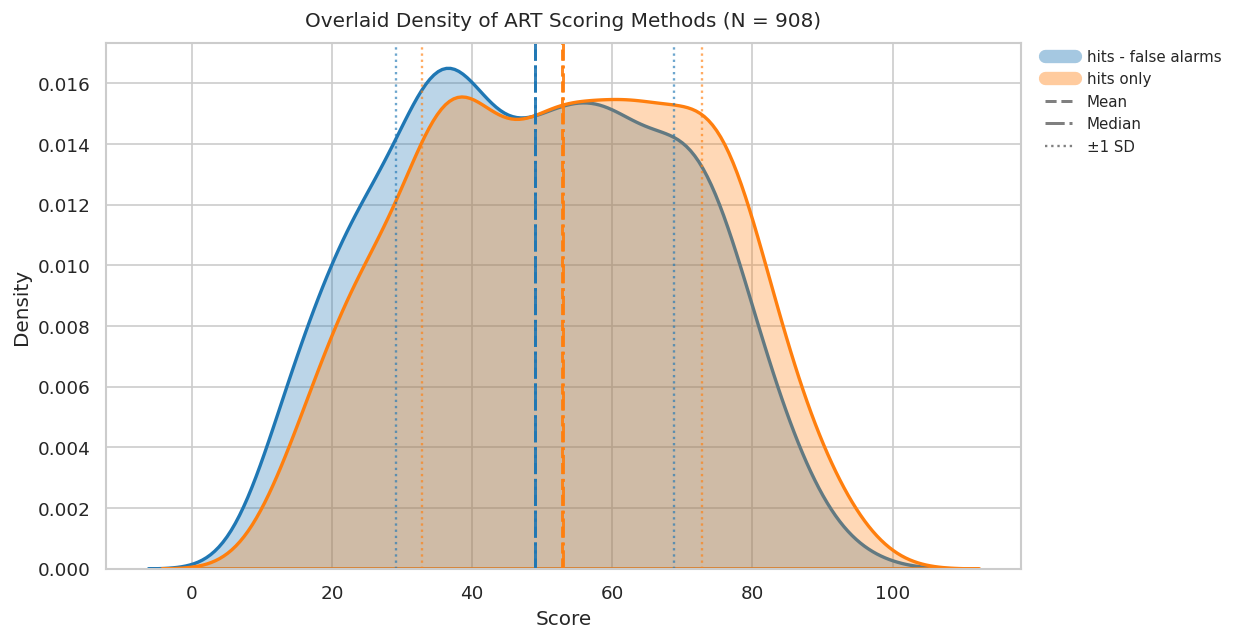


hits - false alarms:  M=48.93, Med=49.00, SD=19.86
hits only:            M=52.77, Med=53.00, SD=19.96


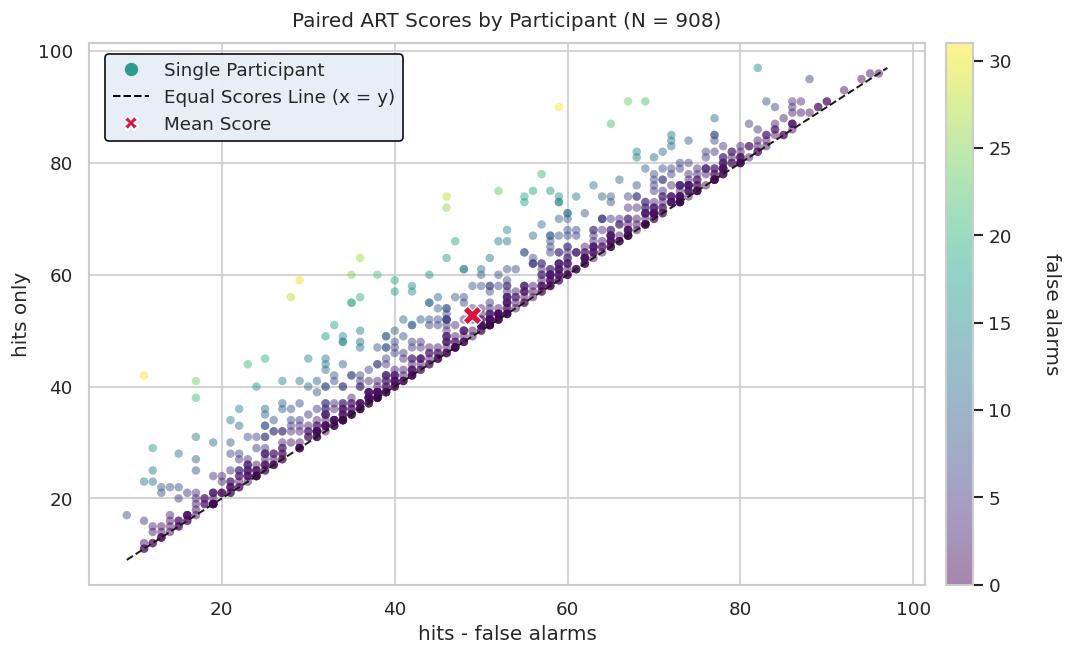


r = 0.97
Mean delta  (hits only - hits - false alarms) = 3.84
Median delta = 2.00
% above y = x (i.e. false alarms > 0) = 78.7%



r = 0.97
Mean delta  = 3.84
Median delta = 2.00
% above y = x = 78.7%


In [8]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns

plot_df = participant_scores_art[
    ["standard_art_score", "art_name_score", "false_alarms"]
].dropna().copy()
plot_df["delta"] = plot_df["art_name_score"] - plot_df["standard_art_score"]

n_plot = len(plot_df)
sns.set_theme(style="whitegrid")

c_standard = "#1f77b4"
c_name     = "#ff7f0e"

m_std    = plot_df["standard_art_score"].mean()
med_std  = plot_df["standard_art_score"].median()
sd_std   = plot_df["standard_art_score"].std(ddof=1)

m_name   = plot_df["art_name_score"].mean()
med_name = plot_df["art_name_score"].median()
sd_name  = plot_df["art_name_score"].std(ddof=1)

corr       = plot_df[["standard_art_score", "art_name_score"]].corr().iloc[0, 1]
mean_delta = plot_df["delta"].mean()
med_delta  = plot_df["delta"].median()
pct_above  = (plot_df["art_name_score"] > plot_df["standard_art_score"]).mean() * 100

line_min = min(plot_df["standard_art_score"].min(), plot_df["art_name_score"].min())
line_max = max(plot_df["standard_art_score"].max(), plot_df["art_name_score"].max())

# ── Figure 1: Overlaid Density ────────────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(10.5, 5.5))

sns.kdeplot(data=plot_df, x="standard_art_score", fill=True, alpha=0.30,
            linewidth=2, color=c_standard, ax=ax1)
sns.kdeplot(data=plot_df, x="art_name_score", fill=True, alpha=0.30,
            linewidth=2, color=c_name, ax=ax1)

for mean_val, med_val, sd_val, color in [
    (m_std,  med_std,  sd_std,  c_standard),
    (m_name, med_name, sd_name, c_name),
]:
    ax1.axvline(mean_val,           color=color, linestyle="--", linewidth=1.8, alpha=0.9)
    ax1.axvline(med_val,            color=color, linestyle="-.", linewidth=1.8, alpha=0.9)
    ax1.axvline(mean_val - sd_val,  color=color, linestyle=":",  linewidth=1.4, alpha=0.65)
    ax1.axvline(mean_val + sd_val,  color=color, linestyle=":",  linewidth=1.4, alpha=0.65)

leg_density = [
    mlines.Line2D([], [], color=c_standard, linewidth=8, alpha=0.4, label="hits - false alarms"),
    mlines.Line2D([], [], color=c_name,     linewidth=8, alpha=0.4, label="hits only"),
    mlines.Line2D([], [], color="gray", linestyle="--", linewidth=1.8, label="Mean"),
    mlines.Line2D([], [], color="gray", linestyle="-.", linewidth=1.8, label="Median"),
    mlines.Line2D([], [], color="gray", linestyle=":",  linewidth=1.4, label="±1 SD"),
]
ax1.legend(handles=leg_density, frameon=False,
           loc="upper left", bbox_to_anchor=(1.02, 1.0),
           borderaxespad=0, fontsize=9)

ax1.set_title(f"Overlaid Density of ART Scoring Methods (N = {n_plot})", fontsize=12, pad=10)
ax1.set_xlabel("Score")
ax1.set_ylabel("Density")
fig1.tight_layout()
plt.show()

print(
    f"\nhits - false alarms:  M={m_std:.2f}, Med={med_std:.2f}, SD={sd_std:.2f}"
    f"\nhits only:            M={m_name:.2f}, Med={med_name:.2f}, SD={sd_name:.2f}"
)

# ── Figure 2: Static paired scatter ──────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(10.5, 5.5))

sc = ax2.scatter(
    plot_df["standard_art_score"],
    plot_df["art_name_score"],
    c=plot_df["false_alarms"],
    cmap="viridis", alpha=0.48, s=26, edgecolors="none",
)
ax2.plot([line_min, line_max], [line_min, line_max], "k--", linewidth=1.2)
ax2.scatter(m_std, m_name, marker="X", s=130, color="crimson",
            edgecolors="white", linewidth=0.8, zorder=5)

ax2.set_title(f"Paired ART Scores by Participant (N = {n_plot})", fontsize=12, pad=10)
ax2.set_xlabel("hits - false alarms")
ax2.set_ylabel("hits only")

leg_scatter = [
    mlines.Line2D([], [], marker="o", color="#2a9d8f", linestyle="None",
                  markersize=7, label="Single Participant"),
    mlines.Line2D([], [], color="black", linestyle="--", linewidth=1.2, label="Equal Scores Line (x = y)"),
    mlines.Line2D([], [], marker="X", color="crimson", linestyle="None",
                  markersize=8, markeredgecolor="white", label="Mean Score"),
]

# Colorbar on the right edge of axes
cbar = fig2.colorbar(sc, ax=ax2, pad=0.02)
# Force upside-down/right-side orientation explicitly
cbar.ax.set_ylabel("false alarms", rotation=270, va="bottom", labelpad=18)

# Keep room for colorbar, and use a clear in-axes legend box
fig2.subplots_adjust(left=0.08, right=0.88, top=0.92, bottom=0.10)
ax2.legend(
    handles=leg_scatter,
    loc="upper left",
    bbox_to_anchor=(0.02, 0.98),
    borderaxespad=0.0,
    frameon=True,
    fancybox=True,
    framealpha=0.95,
    edgecolor="black",
    facecolor="#e6eef7",
    fontsize=11,
)
plt.show()

print(
    f"\nr = {corr:.2f}"
    f"\nMean delta  (hits only - hits - false alarms) = {mean_delta:.2f}"
    f"\nMedian delta = {med_delta:.2f}"
    f"\n% above y = x (i.e. false alarms > 0) = {pct_above:.1f}%"
)

# ── Figure 3: Interactive scatter (Plotly) ────────────────────────────────────
import plotly.graph_objects as go

plot_df_hover = plot_df.copy()
plot_df_hover["false alarms"] = plot_df_hover["false_alarms"].astype(int)

fig_int = go.Figure()

# Main cloud — showlegend=False; colorbar serves as its visual key
fig_int.add_trace(go.Scatter(
    x=plot_df_hover["standard_art_score"],
    y=plot_df_hover["art_name_score"],
    mode="markers",
    showlegend=False,
    marker=dict(
        size=7,
        color=plot_df_hover["false alarms"],
        colorscale="Viridis",
        opacity=0.6,
        colorbar=dict(
            title=dict(text="false alarms", side="right", font=dict(size=12)),
            thickness=14,
            x=1.02,
            xpad=12,
        ),
        showscale=True,
    ),
    customdata=plot_df_hover[["false alarms", "delta"]].values,
    hovertemplate=(
        "<b>hits - false alarms:</b> %{x}<br>"
        "<b>hits only:</b> %{y}<br>"
        "<b>false alarms:</b> %{customdata[0]}<br>"
        "<b>delta:</b> %{customdata[1]:.2f}"
        "<extra></extra>"
    ),
))

# Legend-only marker for participant points (continuous color uses colorbar)
fig_int.add_trace(go.Scatter(
    x=[None], y=[None],
    mode="markers",
    marker=dict(size=9, color="#2a9d8f"),
    name="Single Participant",
    hoverinfo="skip",
))

# x = y reference line
fig_int.add_trace(go.Scatter(
    x=[line_min, line_max], y=[line_min, line_max],
    mode="lines",
    line=dict(color="black", width=1.5, dash="dash"),
    name="Equal Scores Line (x = y)",
    hoverinfo="skip",
))

# Mean marker
fig_int.add_trace(go.Scatter(
    x=[m_std], y=[m_name],
    mode="markers",
    marker=dict(symbol="x", size=14, color="crimson",
                line=dict(color="white", width=1)),
    name="Mean Score",
    hovertemplate=(
        f"Mean Score<br>hits - false alarms: {m_std:.2f}"
        f"<br>hits only: {m_name:.2f}<extra></extra>"
    ),
))

fig_int.update_layout(
    title=dict(
        text=f"Paired ART Scores by Participant (N = {n_plot})",
        font=dict(size=14),
        x=0.5,
        xanchor="center",
        y=0.96,
        yanchor="top",
    ),
    xaxis_title="hits - false alarms",
    yaxis_title="hits only",
    xaxis=dict(title_font=dict(size=12), tickfont=dict(size=10)),
    yaxis=dict(title_font=dict(size=12), tickfont=dict(size=10)),
    font=dict(family="DejaVu Sans", size=11, color="black"),
    autosize=False,
    width=1050,
    height=550,
    legend=dict(
        x=0.02,
        y=0.98,
        xanchor="left",
        yanchor="top",
        traceorder="normal",
        font=dict(size=11),
        bgcolor="LightSteelBlue",
        bordercolor="Black",
        borderwidth=2,
    ),
    margin=dict(t=90, b=60, r=150),
)

fig_int.show()

print(
    f"\nr = {corr:.2f}"
    f"\nMean delta  = {mean_delta:.2f}"
    f"\nMedian delta = {med_delta:.2f}"
    f"\n% above y = x = {pct_above:.1f}%"
)

In [9]:
# Table: author selection rates (sorted by popularity)
author_selection_rates = pd.DataFrame(
    {
        "item_label": author_key["item_label"].values,
        "genre": author_key["genre"].values,
        "n_selected": author_resp_bin.sum(axis=0, skipna=True).values,
        "n_valid": author_resp_bin.notna().sum(axis=0).values,
    }
)

author_selection_rates["selection_rate"] = (
    author_selection_rates["n_selected"] / author_selection_rates["n_valid"].replace(0, np.nan)
)
author_selection_rates["selection_rate_pct"] = (author_selection_rates["selection_rate"] * 100).round(1)

author_selection_rates = author_selection_rates.sort_values(
    "selection_rate", ascending=False
).reset_index(drop=True)
author_selection_rates.insert(0, "rank", author_selection_rates.index + 1)

display(author_selection_rates[["rank", "item_label", "genre", "selection_rate_pct", "n_selected", "n_valid"]])

,rank,item_label,genre,selection_rate_pct,n_selected,n_valid
0,1,Jules Verne,Classics,98.9,898.0,908
1,2,Arthur Conan Doyle,Classics,98.8,897.0,908
2,3,Jack London,Classics,98.5,894.0,908
3,4,Agatha Christie,Detective/Thriller,97.7,887.0,908
4,5,Alexandre Dumas,Classics,97.7,887.0,908
5,6,Charles Dickens,Classics,97.2,883.0,908
6,7,John R.R. Tolkien,Fantasy,97.2,883.0,908
7,8,Ray Bradbury,Sci-Fi,96.7,878.0,908
8,9,Eric Maria Remarque,Classics,96.1,873.0,908
9,10,Haruki Murakami,Modern/Literary,93.5,849.0,908


In [10]:
# Interactive author selection ranking
import plotly.express as px
import plotly.graph_objects as go

plot_df = author_selection_rates.copy()
plot_df = plot_df.dropna(subset=["selection_rate_pct", "n_selected", "n_valid"])
plot_df["n_selected"] = plot_df["n_selected"].astype(float)
plot_df["n_valid"] = plot_df["n_valid"].astype(float)

# Keep order from ranking table (highest first)
item_order_desc = plot_df["item_label"].tolist()
item_order_asc = item_order_desc[::-1]

palette = px.colors.qualitative.Set2
genres = sorted(plot_df["genre"].dropna().unique().tolist())
color_map = {g: palette[i % len(palette)] for i, g in enumerate(genres)}

hover_template = (
    "<b>Author Name:</b> %{customdata[0]}<br>"
    "<b>Genre:</b> %{customdata[1]}<br>"
    "<b>Selection Rate:</b> %{x:.1f}%<br>"
    "<b>n selected:</b> %{customdata[2]:.0f}"
    "<extra></extra>"
)

fig_lollipop = go.Figure()

for _, row in plot_df.iterrows():
    fig_lollipop.add_shape(
        type="line",
        x0=0,
        x1=float(row["selection_rate_pct"]),
        y0=row["item_label"],
        y1=row["item_label"],
        xref="x",
        yref="y",
        line=dict(color=color_map.get(row["genre"], "#999999"), width=1.3),
        opacity=0.75,
    )

for genre_name in genres:
    sub = plot_df[plot_df["genre"] == genre_name]
    fig_lollipop.add_trace(
        go.Scatter(
            x=sub["selection_rate_pct"],
            y=sub["item_label"],
            mode="markers",
            name=genre_name,
            marker=dict(size=9, color=color_map[genre_name], line=dict(width=0.5, color="#333")),
            customdata=sub[["item_label", "genre", "n_selected"]].to_numpy(),
            hovertemplate=hover_template,
        )
    )

fig_lollipop.update_layout(
    # Prevent title/legend/axes from silently inflating margins (Plotly layout reference)
    margin_autoexpand=False,
    title=dict(
        text="<b>Author-Level Selection Rates Across Genres (N = 908)</b>",
        xref="paper",
        yref="paper",
        x=0.5,
        xanchor="center",
        # y must stay in [0, 1] in Plotly layout.title
        y=1.0,
        yanchor="bottom",
        automargin=False,
        pad=dict(t=0, b=0),
    ),
    template="plotly_white",
    height=max(700, int(18 * len(plot_df))),
    margin=dict(t=28, r=155, b=28, l=180, pad=0),
    legend=dict(
        title=dict(text="Genre", font=dict(weight=700)),
        xref="paper",
        yref="paper",
        x=1.005,
        xanchor="left",
        # Top of legend aligned with top of plotting area (same band as first author row)
        y=1.0,
        yanchor="top",
        valign="top",
    ),
)
fig_lollipop.update_xaxes(
    range=[0, 100],
    automargin=False,
    title=dict(text="<b>Selection Rate (%)</b>", standoff=11),
)
fig_lollipop.update_yaxes(
    automargin=False,
    title=dict(text="<b>Author Name</b>", standoff=4),
    categoryorder="array",
    categoryarray=item_order_asc,
)
fig_lollipop.show()

## 3) Table 3-style foil-error distribution

Percentages of participants by number of foil selections (false alarms), matching Table 3 column structure (`Errors`, `%`).

In [11]:
fa_counts = false_alarms.fillna(0).astype(int)
max_fa = int(fa_counts.max())

# 5-wide bins: 0-5, 5-10, 10-15, 15-20, 20-25, 25-30, 30-35
bin_starts = list(range(0, 35, 5))
table3_rows = []
for start in bin_starts:
    end = start + 5
    if start == 30:
        pct = ((fa_counts >= start) & (fa_counts <= end)).mean() * 100
    else:
        pct = ((fa_counts >= start) & (fa_counts < end)).mean() * 100
    table3_rows.append({"Errors": f"{start}-{end}", "%": pct})

table3_art = pd.DataFrame(table3_rows)
table3_art["%"] = table3_art["%"].round(1)

display(table3_art)
print(f"N = {len(fa_counts)}")

mean_val = fa_counts.mean()
median_val = fa_counts.median()
std_val = fa_counts.std()
min_val = int(fa_counts.min())
max_val = int(fa_counts.max())
q1 = fa_counts.quantile(0.25)
q3 = fa_counts.quantile(0.75)
iqr = q3 - q1
pct_ge_6 = (fa_counts >= 6).mean() * 100

print(f"Mean: {mean_val:.2f}")
print(f"Median: {median_val:.2f}")
print(f"Range: {min_val}-{max_val} (width={max_val - min_val})")
print(f"Std: {std_val:.2f}")
print(f"Q1: {q1:.2f}")
print(f"Q3: {q3:.2f}")
print(f"IQR: {iqr:.2f}")
print(f"% >= 6: {pct_ge_6:.1f}%")

,Errors,%
0,0-5,71.6
1,5-10,17.1
2,10-15,6.8
3,15-20,2.2
4,20-25,1.4
5,25-30,0.6
6,30-35,0.3


N = 908
Mean: 3.84
Median: 2.00
Range: 0-31 (width=31)
Std: 5.01
Q1: 1.00
Q3: 5.00
IQR: 4.00
% >= 6: 24.2%


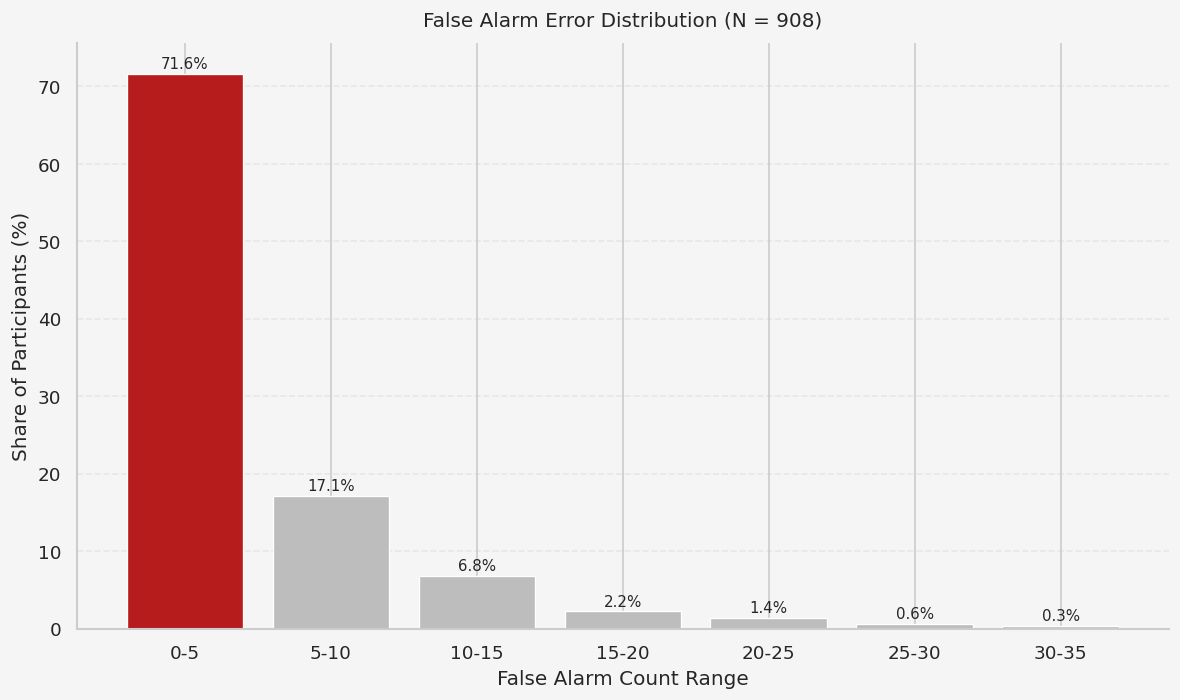

In [12]:
# Ordered bar chart for false alarm error distribution

plot_df = table3_art.copy()
plot_df["%"] = pd.to_numeric(plot_df["%"], errors="coerce")
ordered_df = plot_df.sort_values("%", ascending=False).reset_index(drop=True)

n_obs = len(fa_counts) if "fa_counts" in globals() else 908
highlight_label = ordered_df.loc[0, "Errors"]

# One red bar for the highest %, grey for all others
base_color = "#BDBDBD"
highlight_color = "#B71C1C"
colors_highlight = [highlight_color if lbl == highlight_label else base_color for lbl in ordered_df["Errors"]]

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor("whitesmoke")
ax.set_facecolor("whitesmoke")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

bars = ax.bar(ordered_df["Errors"], ordered_df["%"], color=colors_highlight, edgecolor="white", linewidth=0.8)
ax.set_title(f"False Alarm Error Distribution (N = {n_obs})")
ax.set_xlabel("False Alarm Count Range")
ax.set_ylabel("Share of Participants (%)")
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.set_ylim(0, ordered_df["%"].max() + 4)

for b in bars:
    h = b.get_height()
    ax.text(b.get_x() + b.get_width() / 2, h + 0.35, f"{h:.1f}%", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

In [13]:
# Table: foil selection rates (sorted by popularity)
foil_selection_rates = pd.DataFrame(
    {
        "item_label": foil_key["item_label"].values,
        "genre": foil_key["genre"].values,
        "n_selected": foil_resp_bin.sum(axis=0, skipna=True).values,
        "n_valid": foil_resp_bin.notna().sum(axis=0).values,
    }
)

foil_selection_rates["selection_rate"] = (
    foil_selection_rates["n_selected"] / foil_selection_rates["n_valid"].replace(0, np.nan)
)
foil_selection_rates["selection_rate_pct"] = (foil_selection_rates["selection_rate"] * 100).round(1)

foil_selection_rates = foil_selection_rates.sort_values(
    "selection_rate", ascending=False
).reset_index(drop=True)
foil_selection_rates.insert(0, "rank", foil_selection_rates.index + 1)

display(foil_selection_rates[["rank", "item_label", "genre", "selection_rate_pct", "n_selected", "n_valid"]])

,rank,item_label,genre,selection_rate_pct,n_selected,n_valid
0,1,Paul Williams,Foil,19.5,177,908
1,2,Valentin Levin,Foil,18.9,172,908
2,3,Vladimir Pozdnyakov,Foil,16.0,145,908
3,4,German Sadulayev,Foil,13.2,120,908
4,5,Alexander Fomin,Foil,11.1,101,908
5,6,Elizabeth Harlett,Foil,10.4,94,908
6,7,Jeremy Watts,Foil,10.2,93,908
7,8,Gennady Proskurin,Foil,10.1,92,908
8,9,Leonid Golovnin,Foil,9.1,83,908
9,10,Valentin Vershinin,Foil,8.9,81,908


In [14]:
# Table: author selection rates by genre (participant-level, sorted by popularity)
genre_to_item_ids = author_key.groupby("genre")["item_id"].apply(list).to_dict()

genre_rows = []
for genre, item_ids in genre_to_item_ids.items():
    genre_mat = author_resp_bin[item_ids]
    n_items = len(item_ids)

    # Participant-level coverage (bounded by sample size)
    answered_any = genre_mat.notna().sum(axis=1) > 0
    selected_any = genre_mat.fillna(0).sum(axis=1) > 0

    n_valid = int(answered_any.sum())
    n_selected_any = int(selected_any.sum())
    selected_any_pct = (n_selected_any / n_valid * 100) if n_valid else np.nan

    # Mean within-participant endorsement proportion for this genre
    participant_genre_rate = genre_mat.mean(axis=1, skipna=True)
    selection_rate_pct = (
        participant_genre_rate.mean() * 100 if participant_genre_rate.notna().any() else np.nan
    )

    genre_rows.append(
        {
            "genre": genre,
            "n_items": n_items,
            "selection_rate_pct": selection_rate_pct,
            "n_selected_any": n_selected_any,
            "selected_any_pct": selected_any_pct,
            "n_valid": n_valid,
        }
    )

genre_selection_rates = pd.DataFrame(genre_rows)
genre_selection_rates[["selection_rate_pct", "selected_any_pct"]] = genre_selection_rates[
    ["selection_rate_pct", "selected_any_pct"]
].round(1)
genre_selection_rates = genre_selection_rates.sort_values(
    "selection_rate_pct", ascending=False
).reset_index(drop=True)
genre_selection_rates.insert(0, "rank", genre_selection_rates.index + 1)

display(
    genre_selection_rates[
        [
            "rank",
            "genre",
            "n_items",
            "selection_rate_pct",
            "n_selected_any",
            "selected_any_pct",
            "n_valid",
        ]
    ]
)

print(
    "Interpretation: 'selection_rate_pct' is the mean share of items selected within a genre "
    "(intensity). 'n_selected_any' is the number of participants who selected at least one "
    "author from that genre (coverage), and 'selected_any_pct' is that coverage as a percentage "
    "of 'n_valid'."
)

,rank,genre,n_items,selection_rate_pct,n_selected_any,selected_any_pct,n_valid
0,1,Sci-Fi,5,73.9,899,99.0,908
1,2,Fantasy,7,66.7,902,99.3,908
2,3,Classics,30,62.5,908,100.0,908
3,4,SovLit,14,55.1,864,95.2,908
4,5,Detective/Thriller,10,53.9,905,99.7,908
5,6,Modern/Literary,32,39.2,906,99.8,908


Interpretation: 'selection_rate_pct' is the mean share of items selected within a genre (intensity). 'n_selected_any' is the number of participants who selected at least one author from that genre (coverage), and 'selected_any_pct' is that coverage as a percentage of 'n_valid'.


In [15]:
# Genre selection ranking (grouped horizontal bars for 2 metrics)
import plotly.graph_objects as go

plot_df = genre_selection_rates.copy()
plot_df = plot_df.dropna(subset=["selection_rate_pct", "selected_any_pct", "n_items", "genre", "rank"])
plot_df["rank"] = plot_df["rank"].astype(int)
plot_df["n_items"] = plot_df["n_items"].astype(int)
plot_df = plot_df.sort_values("selection_rate_pct", ascending=False).reset_index(drop=True)
plot_df["genre_label"] = plot_df["rank"].astype(str) + ". " + plot_df["genre"].astype(str)

common_customdata = plot_df[["genre", "n_items", "selection_rate_pct", "selected_any_pct"]].to_numpy()

fig_genre_grouped = go.Figure()

fig_genre_grouped.add_trace(
    go.Bar(
        x=plot_df["selection_rate_pct"],
        y=plot_df["genre_label"],
        orientation="h",
        name="Selection Rate (%)",
        marker=dict(color="#2a9d8f"),
        customdata=common_customdata,
        hovertemplate=(
            "<b>Genre:</b> %{customdata[0]}<br>"
            "<b>n items:</b> %{customdata[1]:.0f}<br>"
            "<b>Selection Rate:</b> %{customdata[2]:.1f}%<br>"
            "<b>Selected Any:</b> %{customdata[3]:.1f}%"
            "<extra></extra>"
        ),
    )
)

fig_genre_grouped.add_trace(
    go.Bar(
        x=plot_df["selected_any_pct"],
        y=plot_df["genre_label"],
        orientation="h",
        name="Selected Any (%)",
        marker=dict(color="#e76f51"),
        customdata=common_customdata,
        hovertemplate=(
            "<b>Genre:</b> %{customdata[0]}<br>"
            "<b>n items:</b> %{customdata[1]:.0f}<br>"
            "<b>Selection Rate:</b> %{customdata[2]:.1f}%<br>"
            "<b>Selected Any:</b> %{customdata[3]:.1f}%"
            "<extra></extra>"
        ),
    )
)

fig_genre_grouped.update_layout(
    title=dict(text="<b>Genre Intensity vs Coverage (Grouped Bars)</b>", x=0.5),
    template="plotly_white",
    barmode="group",
    height=520,
    margin=dict(t=48, r=40, b=40, l=190),
    legend=dict(x=0.0, y=1.08, orientation="h"),
)
fig_genre_grouped.update_xaxes(range=[0, 100], title=dict(text="<b>Percentage (%)</b>"))
fig_genre_grouped.update_yaxes(
    title=dict(text="<b>Genre (Rank)</b>"),
    categoryorder="array",
    categoryarray=plot_df["genre_label"].tolist()[::-1],
)

fig_genre_grouped.show()

In [16]:
# 4) Item flag thresholds (flags for review, NOT automatic deletion)

import numpy as np
import pandas as pd

# --- helper: corrected item-total correlation (author items) ---
def corrected_item_total_corr(df_bin: pd.DataFrame) -> pd.Series:
    """
    Compute corrected item-total correlation per item.
    Correlates each item with total score excluding that item, using row-wise available data.
    """
    out = {}
    for col in df_bin.columns:
        x = df_bin[col]
        valid = x.notna()
        if valid.sum() < 3:
            out[col] = np.nan
            continue

        sub = df_bin.loc[valid]
        x_valid = x.loc[valid]
        corrected_total = sub.sum(axis=1, skipna=True) - x_valid

        # Guard against zero variance
        if x_valid.nunique(dropna=True) < 2 or corrected_total.nunique(dropna=True) < 2:
            out[col] = np.nan
        else:
            out[col] = x_valid.corr(corrected_total)

    return pd.Series(out, name="corrected_item_total_corr")


# --- source tables expected from previous cells ---
# author_selection_rates columns: rank, item_label, genre, selection_rate_pct, n_selected, n_valid
# foil_selection_rates   columns: rank, item_label, genre, selection_rate_pct, n_selected, n_valid
# author_resp_bin: participant x author-item binary response matrix

author_flags = author_selection_rates.copy()
foil_flags = foil_selection_rates.copy()

author_flags["selection_rate"] = author_flags["selection_rate_pct"] / 100.0
foil_flags["selection_rate"] = foil_flags["selection_rate_pct"] / 100.0

# Corrected item-total correlation for author items
citc = corrected_item_total_corr(author_resp_bin)
author_flags = author_flags.merge(
    citc.rename_axis("item_label").reset_index(),
    on="item_label",
    how="left",
)

# ------------------------------
# A) Fixed rule flags from request
# ------------------------------
author_flags["flag_endorsement_extreme_<.05_or_>.95"] = (
    (author_flags["selection_rate"] < 0.05) | (author_flags["selection_rate"] > 0.95)
)
author_flags["flag_citc_<.10"] = author_flags["corrected_item_total_corr"] < 0.10
author_flags["flag_citc_negative"] = author_flags["corrected_item_total_corr"] < 0

author_flags["flag_author_any_requested"] = (
    author_flags["flag_endorsement_extreme_<.05_or_>.95"]
    | author_flags["flag_citc_<.10"]
    | author_flags["flag_citc_negative"]
)

# ------------------------------
# B) Multi-threshold endorsement flags for BOTH author and foil pools
# ------------------------------
def add_multi_threshold_flags(df: pd.DataFrame, value_col: str, prefix: str, fixed_threshold: float = 0.20) -> pd.DataFrame:
    mean_val = df[value_col].mean()
    std_val = df[value_col].std(ddof=0)
    q1 = df[value_col].quantile(0.25)
    q3 = df[value_col].quantile(0.75)
    iqr = q3 - q1
    p95 = df[value_col].quantile(0.95)

    z_col = f"{prefix}_z"
    flag_z_col = f"flag_{prefix}_z_>2"
    flag_iqr_col = f"flag_{prefix}_iqr_>Q3+1.5IQR"
    flag_p95_col = f"flag_{prefix}_top_5pct_>P95"
    flag_fixed_col = f"flag_{prefix}_fixed_>0.20"
    flag_any_col = f"flag_{prefix}_any_threshold"

    out = df.copy()
    out[z_col] = (out[value_col] - mean_val) / std_val if std_val and std_val > 0 else np.nan
    out[flag_z_col] = out[z_col] > 2
    out[flag_iqr_col] = out[value_col] > (q3 + 1.5 * iqr)
    out[flag_p95_col] = out[value_col] > p95
    out[flag_fixed_col] = out[value_col] > fixed_threshold
    out[flag_any_col] = out[[flag_z_col, flag_iqr_col, flag_p95_col, flag_fixed_col]].any(axis=1)
    return out

author_flags = add_multi_threshold_flags(
    author_flags,
    value_col="selection_rate",
    prefix="author_endorsement",
    fixed_threshold=0.20,
)

foil_flags = add_multi_threshold_flags(
    foil_flags,
    value_col="selection_rate",
    prefix="foil_endorsement",
    fixed_threshold=0.20,
)

# ------------------------------
# C) Very high missingness via multiple threshold styles for BOTH pools (separately)
# ------------------------------
author_missing_df = author_flags[["item_label", "genre", "n_valid", "selection_rate_pct"]].copy()
author_missing_df["item_type"] = "author"
author_missing_df["missing_rate"] = 1 - (
    author_missing_df["n_valid"] / author_missing_df["n_valid"].max()
)
author_missing_df["missing_rate_pct"] = author_missing_df["missing_rate"] * 100

author_missing_df = add_multi_threshold_flags(
    author_missing_df,
    value_col="missing_rate",
    prefix="author_missingness",
    fixed_threshold=0.20,
)

foil_missing_df = foil_flags[["item_label", "genre", "n_valid", "selection_rate_pct"]].copy()
foil_missing_df["item_type"] = "foil"
foil_missing_df["missing_rate"] = 1 - (
    foil_missing_df["n_valid"] / foil_missing_df["n_valid"].max()
)
foil_missing_df["missing_rate_pct"] = foil_missing_df["missing_rate"] * 100

foil_missing_df = add_multi_threshold_flags(
    foil_missing_df,
    value_col="missing_rate",
    prefix="foil_missingness",
    fixed_threshold=0.20,
)

missing_df = pd.concat([author_missing_df, foil_missing_df], ignore_index=True)

# ------------------------------
# D) Printed tables
# ------------------------------
print("\n=== Requested fixed-rule flags (AUTHOR items) ===")
display(
    author_flags.loc[
        author_flags["flag_author_any_requested"],
        [
            "rank",
            "item_label",
            "genre",
            "selection_rate_pct",
            "n_selected",
            "n_valid",
            "corrected_item_total_corr",
            "flag_endorsement_extreme_<.05_or_>.95",
            "flag_citc_<.10",
            "flag_citc_negative",
        ],
    ].sort_values(["flag_citc_negative", "flag_citc_<.10", "selection_rate_pct"], ascending=[False, False, True])
)

print("\n=== Author endorsement outlier flags (multiple threshold methods) ===")
display(
    author_flags.loc[
        author_flags["flag_author_endorsement_any_threshold"],
        [
            "rank",
            "item_label",
            "selection_rate_pct",
            "n_selected",
            "n_valid",
            "author_endorsement_z",
            "flag_author_endorsement_z_>2",
            "flag_author_endorsement_iqr_>Q3+1.5IQR",
            "flag_author_endorsement_top_5pct_>P95",
            "flag_author_endorsement_fixed_>0.20",
        ],
    ].sort_values("selection_rate_pct", ascending=False)
)

print("\n=== Foil endorsement outlier flags (multiple threshold methods) ===")
display(
    foil_flags.loc[
        foil_flags["flag_foil_endorsement_any_threshold"],
        [
            "rank",
            "item_label",
            "selection_rate_pct",
            "n_selected",
            "n_valid",
            "foil_endorsement_z",
            "flag_foil_endorsement_z_>2",
            "flag_foil_endorsement_iqr_>Q3+1.5IQR",
            "flag_foil_endorsement_top_5pct_>P95",
            "flag_foil_endorsement_fixed_>0.20",
        ],
    ].sort_values("selection_rate_pct", ascending=False)
)

print("\n=== Very high missingness flags (AUTHOR pool; multiple threshold methods) ===")
display(
    author_missing_df.loc[
        author_missing_df["flag_author_missingness_any_threshold"],
        [
            "item_type",
            "item_label",
            "genre",
            "n_valid",
            "missing_rate_pct",
            "author_missingness_z",
            "flag_author_missingness_z_>2",
            "flag_author_missingness_iqr_>Q3+1.5IQR",
            "flag_author_missingness_top_5pct_>P95",
            "flag_author_missingness_fixed_>0.20",
        ],
    ].sort_values("missing_rate_pct", ascending=False)
)

print("\n=== Very high missingness flags (FOIL pool; multiple threshold methods) ===")
display(
    foil_missing_df.loc[
        foil_missing_df["flag_foil_missingness_any_threshold"],
        [
            "item_type",
            "item_label",
            "genre",
            "n_valid",
            "missing_rate_pct",
            "foil_missingness_z",
            "flag_foil_missingness_z_>2",
            "flag_foil_missingness_iqr_>Q3+1.5IQR",
            "flag_foil_missingness_top_5pct_>P95",
            "flag_foil_missingness_fixed_>0.20",
        ],
    ].sort_values("missing_rate_pct", ascending=False)
)

summary_flags = pd.DataFrame(
    {
        "rule": [
            "Author endorsement <.05 or >.95",
            "Author corrected item-total <.10",
            "Author corrected item-total negative",
            "Author endorsement z > 2",
            "Author endorsement > Q3 + 1.5*IQR",
            "Author endorsement > P95",
            "Author endorsement > 0.20",
            "Foil endorsement z > 2",
            "Foil endorsement > Q3 + 1.5*IQR",
            "Foil endorsement > P95",
            "Foil endorsement > 0.20",
            "Author missingness z > 2",
            "Author missingness > Q3 + 1.5*IQR",
            "Author missingness > P95",
            "Author missingness > 0.20",
            "Foil missingness z > 2",
            "Foil missingness > Q3 + 1.5*IQR",
            "Foil missingness > P95",
            "Foil missingness > 0.20",
        ],
        "n_flagged": [
            int(author_flags["flag_endorsement_extreme_<.05_or_>.95"].sum()),
            int(author_flags["flag_citc_<.10"].sum()),
            int(author_flags["flag_citc_negative"].sum()),
            int(author_flags["flag_author_endorsement_z_>2"].sum()),
            int(author_flags["flag_author_endorsement_iqr_>Q3+1.5IQR"].sum()),
            int(author_flags["flag_author_endorsement_top_5pct_>P95"].sum()),
            int(author_flags["flag_author_endorsement_fixed_>0.20"].sum()),
            int(foil_flags["flag_foil_endorsement_z_>2"].sum()),
            int(foil_flags["flag_foil_endorsement_iqr_>Q3+1.5IQR"].sum()),
            int(foil_flags["flag_foil_endorsement_top_5pct_>P95"].sum()),
            int(foil_flags["flag_foil_endorsement_fixed_>0.20"].sum()),
            int(author_missing_df["flag_author_missingness_z_>2"].sum()),
            int(author_missing_df["flag_author_missingness_iqr_>Q3+1.5IQR"].sum()),
            int(author_missing_df["flag_author_missingness_top_5pct_>P95"].sum()),
            int(author_missing_df["flag_author_missingness_fixed_>0.20"].sum()),
            int(foil_missing_df["flag_foil_missingness_z_>2"].sum()),
            int(foil_missing_df["flag_foil_missingness_iqr_>Q3+1.5IQR"].sum()),
            int(foil_missing_df["flag_foil_missingness_top_5pct_>P95"].sum()),
            int(foil_missing_df["flag_foil_missingness_fixed_>0.20"].sum()),
        ],
    }
)

print("\n=== Flag count summary ===")
display(summary_flags)

print("\nNote: These are review flags only and should not be used as automatic deletion rules.")


=== Requested fixed-rule flags (AUTHOR items) ===


,rank,item_label,genre,selection_rate_pct,n_selected,n_valid,corrected_item_total_corr,flag_endorsement_extreme_<.05_or_>.95,flag_citc_<.10,flag_citc_negative
0,1,Jules Verne,Classics,98.9,898.0,908,0.057591,True,True,False
97,98,Yustein Gordier,Modern/Literary,4.1,37.0,908,0.201770,True,False,False
8,9,Eric Maria Remarque,Classics,96.1,873.0,908,0.262063,True,False,False
7,8,Ray Bradbury,Sci-Fi,96.7,878.0,908,0.267905,True,False,False
5,6,Charles Dickens,Classics,97.2,883.0,908,0.260383,True,False,False
6,7,John R.R. Tolkien,Fantasy,97.2,883.0,908,0.192302,True,False,False
3,4,Agatha Christie,Detective/Thriller,97.7,887.0,908,0.183447,True,False,False
4,5,Alexandre Dumas,Classics,97.7,887.0,908,0.191184,True,False,False
2,3,Jack London,Classics,98.5,894.0,908,0.196983,True,False,False
1,2,Arthur Conan Doyle,Classics,98.8,897.0,908,0.114452,True,False,False



=== Author endorsement outlier flags (multiple threshold methods) ===


,rank,item_label,selection_rate_pct,n_selected,n_valid,author_endorsement_z,flag_author_endorsement_z_>2,flag_author_endorsement_iqr_>Q3+1.5IQR,flag_author_endorsement_top_5pct_>P95,flag_author_endorsement_fixed_>0.20
0,1,Jules Verne,98.9,898.0,908,1.731420,False,False,True,True
1,2,Arthur Conan Doyle,98.8,897.0,908,1.727576,False,False,True,True
2,3,Jack London,98.5,894.0,908,1.716045,False,False,True,True
3,4,Agatha Christie,97.7,887.0,908,1.685296,False,False,True,True
4,5,Alexandre Dumas,97.7,887.0,908,1.685296,False,False,True,True
5,6,Charles Dickens,97.2,883.0,908,1.666077,False,False,False,True
6,7,John R.R. Tolkien,97.2,883.0,908,1.666077,False,False,False,True
7,8,Ray Bradbury,96.7,878.0,908,1.646859,False,False,False,True
8,9,Eric Maria Remarque,96.1,873.0,908,1.623797,False,False,False,True
9,10,Haruki Murakami,93.5,849.0,908,1.523861,False,False,False,True



=== Foil endorsement outlier flags (multiple threshold methods) ===


...


=== Very high missingness flags (FOIL pool; multiple threshold methods) ===


,item_type,item_label,genre,n_valid,missing_rate_pct,foil_missingness_z,flag_foil_missingness_z_>2,flag_foil_missingness_iqr_>Q3+1.5IQR,flag_foil_missingness_top_5pct_>P95,flag_foil_missingness_fixed_>0.20



=== Flag count summary ===


,rule,n_flagged
0,Author endorsement <.05 or >.95,10
1,Author corrected item-total <.10,1
2,Author corrected item-total negative,0
3,Author endorsement z > 2,0
4,Author endorsement > Q3 + 1.5*IQR,0
5,Author endorsement > P95,5
6,Author endorsement > 0.20,85
7,Foil endorsement z > 2,4
8,Foil endorsement > Q3 + 1.5*IQR,5
9,Foil endorsement > P95,6



Note: These are review flags only and should not be used as automatic deletion rules.


In [ ]:
# 5) Export dimensionality inputs (for separate R notebook / environment)

import re
from pathlib import Path


# ------------------------------
# A) Output folder
# ------------------------------
DIM_OUT_DIR = (
    PROJECT_ROOT
    / "data"
    / "stepwise_cleaned_versions"
    / "05_dimensionality_inputs"
)
DIM_OUT_DIR.mkdir(parents=True, exist_ok=True)


# ------------------------------
# B) Helpers
# ------------------------------

def _to_snake(text: str) -> str:
    text = re.sub(r"\s+", "_", str(text).strip().lower())
    text = re.sub(r"[^a-z0-9_]+", "_", text)
    text = re.sub(r"_+", "_", text).strip("_")
    return text or "col"


def _make_unique(names):
    seen = {}
    out = []
    for n in names:
        base = str(n)
        if base not in seen:
            seen[base] = 0
            out.append(base)
        else:
            seen[base] += 1
            out.append(f"{base}_{seen[base]}")
    return out


# ------------------------------
# C) Participant-level table: IDs + demographics
# ------------------------------
non_item_indices = np.flatnonzero((~item_mask).to_numpy())
participant_demographics = responses.iloc[:, non_item_indices].copy()

raw_demo_names = labels.iloc[non_item_indices].astype(str).tolist()
raw_demo_names = [n if n.strip() else f"unnamed_{i}" for i, n in enumerate(raw_demo_names)]
participant_demographics.columns = _make_unique([_to_snake(n) for n in raw_demo_names])

participant_id = pd.Series(np.arange(1, len(responses) + 1), name="participant_id")
participant_demographics.insert(0, "participant_id", participant_id)


# ------------------------------
# D) Author/Foil matrix exports with stable matrix item IDs
# ------------------------------
# Keep all cleaned author items currently in author_resp_bin (post-cleaning, post-deduplication).
author_colmap = pd.DataFrame(
    {
        "matrix_item_id": [f"A{i:03d}" for i in range(1, author_resp_bin.shape[1] + 1)],
        "item_id_in_notebook": author_resp_bin.columns,
    }
)
foil_colmap = pd.DataFrame(
    {
        "matrix_item_id": [f"F{i:03d}" for i in range(1, foil_resp_bin.shape[1] + 1)],
        "item_id_in_notebook": foil_resp_bin.columns,
    }
)

author_matrix = author_resp_bin.copy()
author_matrix.columns = author_colmap["matrix_item_id"].tolist()
author_matrix.insert(0, "participant_id", participant_id)

foil_matrix = foil_resp_bin.copy()
foil_matrix.columns = foil_colmap["matrix_item_id"].tolist()
foil_matrix.insert(0, "participant_id", participant_id)


# ------------------------------
# E) Item key exports (with available diagnostics)
# ------------------------------
author_key_base = author_key[["item_id", "item_label", "item_code_norm", "genre"]].copy()
author_key_export = author_colmap.merge(
    author_key_base,
    left_on="item_id_in_notebook",
    right_on="item_id",
    how="left",
)

if "author_selection_rates" in globals():
    author_key_export = author_key_export.merge(
        author_selection_rates[["item_label", "selection_rate_pct", "n_selected", "n_valid"]],
        on="item_label",
        how="left",
    )

if "citc" in globals():
    author_key_export = author_key_export.merge(
        citc.rename_axis("item_label").reset_index(),
        on="item_label",
        how="left",
    )

if "author_flags" in globals():
    keep_cols = [
        c for c in [
            "item_label",
            "flag_endorsement_extreme_<.05_or_>.95",
            "flag_citc_<.10",
            "flag_citc_negative",
            "flag_author_any_requested",
            "flag_author_endorsement_any_threshold",
        ]
        if c in author_flags.columns
    ]
    if keep_cols:
        author_key_export = author_key_export.merge(
            author_flags[keep_cols].drop_duplicates("item_label"),
            on="item_label",
            how="left",
        )

foil_key_base = foil_key[["item_id", "item_label", "item_code_norm", "genre"]].copy()
foil_key_export = foil_colmap.merge(
    foil_key_base,
    left_on="item_id_in_notebook",
    right_on="item_id",
    how="left",
)

if "foil_selection_rates" in globals():
    foil_key_export = foil_key_export.merge(
        foil_selection_rates[["item_label", "selection_rate_pct", "n_selected", "n_valid"]],
        on="item_label",
        how="left",
    )

if "foil_flags" in globals():
    keep_cols = [
        c for c in [
            "item_label",
            "flag_foil_endorsement_any_threshold",
        ]
        if c in foil_flags.columns
    ]
    if keep_cols:
        foil_key_export = foil_key_export.merge(
            foil_flags[keep_cols].drop_duplicates("item_label"),
            on="item_label",
            how="left",
        )


# ------------------------------
# F) Participant scoring summary export
# ------------------------------
participant_summary = pd.DataFrame({"participant_id": participant_id})
participant_summary["author_hits"] = author_resp_bin.sum(axis=1, skipna=True).values
participant_summary["author_missing_n"] = author_resp_bin.isna().sum(axis=1).values
participant_summary["author_missing_rate"] = (
    participant_summary["author_missing_n"] / author_resp_bin.shape[1]
)
participant_summary["foil_false_alarms"] = foil_resp_bin.sum(axis=1, skipna=True).values
participant_summary["foil_missing_n"] = foil_resp_bin.isna().sum(axis=1).values
participant_summary["foil_missing_rate"] = (
    participant_summary["foil_missing_n"] / foil_resp_bin.shape[1]
)

if "participant_scores_art" in globals():
    tmp_scores = participant_scores_art.copy().reset_index(drop=True)
    tmp_scores.insert(0, "participant_id", participant_id)
    participant_summary = participant_summary.merge(tmp_scores, on="participant_id", how="left")


# ------------------------------
# G) Write CSV outputs
# ------------------------------
paths = {
    "author_matrix": DIM_OUT_DIR / "ART_pretest_(for Castano)_EN__dimensionality_input__author_response_matrix.csv",
    "author_item_key": DIM_OUT_DIR / "ART_pretest_(for Castano)_EN__dimensionality_input__author_item_key.csv",
    "foil_matrix": DIM_OUT_DIR / "ART_pretest_(for Castano)_EN__dimensionality_input__foil_response_matrix.csv",
    "foil_item_key": DIM_OUT_DIR / "ART_pretest_(for Castano)_EN__dimensionality_input__foil_item_key.csv",
    "participant_demographics": DIM_OUT_DIR / "ART_pretest_(for Castano)_EN__dimensionality_input__participant_demographics.csv",
    "participant_summary": DIM_OUT_DIR / "ART_pretest_(for Castano)_EN__dimensionality_input__participant_summary.csv",
    "manifest": DIM_OUT_DIR / "ART_pretest_(for Castano)_EN__dimensionality_input__manifest.csv",
}

author_matrix.to_csv(paths["author_matrix"], index=False)
author_key_export.to_csv(paths["author_item_key"], index=False)
foil_matrix.to_csv(paths["foil_matrix"], index=False)
foil_key_export.to_csv(paths["foil_item_key"], index=False)
participant_demographics.to_csv(paths["participant_demographics"], index=False)
participant_summary.to_csv(paths["participant_summary"], index=False)

manifest = pd.DataFrame(
    {
        "field": [
            "source_data_path",
            "n_participants",
            "n_author_items",
            "n_foil_items",
            "author_item_id_scheme",
            "foil_item_id_scheme",
            "author_item_exclusion",
            "foil_item_exclusions",
            "note",
        ],
        "value": [
            str(DATA_PATH),
            str(len(responses)),
            str(author_resp_bin.shape[1]),
            str(foil_resp_bin.shape[1]),
            "A001..Axxx",
            "F001..Fxxx",
            "Richard Feynman (cla17)",
            "Sergey Siptits, Chabo Chucky, Gerrit HoogenbuM",
            "Author matrix is primary for dimensionality; foil matrix is exported for response-style diagnostics.",
        ],
    }
)
manifest.to_csv(paths["manifest"], index=False)

print("Dimensionality input CSVs exported:")
for k, v in paths.items():
    print(f"- {k}: {v}")

print("\nQuick shape check:")
print(f"- author_matrix: {author_matrix.shape}")
print(f"- foil_matrix: {foil_matrix.shape}")
print(f"- participant_demographics: {participant_demographics.shape}")
print(f"- participant_summary: {participant_summary.shape}")
print(f"- author_item_key: {author_key_export.shape}")
print(f"- foil_item_key: {foil_key_export.shape}")